# Sweet Lift Taxi: Predicting Hourly Order Demand

## 1. Project Description

This project focuses on developing a machine learning model to predict the number of taxi orders at the airport for the upcoming hour. The primary goal is to help the company, **Sweet Lift Taxi**, optimize its driver management by ensuring enough vehicles are available during peak hours.

The proposed solution will analyze historical order data and use time series forecasting techniques to achieve a precise prediction, aiming for a **Root Mean Squared Error (RMSE) of less than 48** on the test set.

### Data Description

The data is stored in the `taxi.csv` file. The number of orders is in the `num_orders` column. The dataset covers order history from March 1 to August 31, 2018.

## Data Loading 

In [ ]:
# Third-party libraries (Alphabetical)
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from time import time
import time

# Model evaluation and selection modules
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Time series analysis tools
from statsmodels.tsa.seasonal import seasonal_decompose

## 2. Data Loading and Resampling

We will load the data, set the time series index, and resample the data to an hourly frequency (`1H`) as required for the prediction task.

In [2]:
# Load the data and handle potential errors
try:
    # Load with parse_dates and index_col for cleaner initial data handling
    data = pd.read_csv('taxi.csv', index_col=0, parse_dates=[0])
    
    # Ensure the data is chronologically sorted (essential for time series)
    data.sort_index(inplace=True)
    
    # Resample the data to an hourly frequency and sum the orders
    # ⚠️ Use 'h' instead of 'H' to avoid FutureWarning in future pandas versions
    data_hourly = data.resample('1h').sum()
    
    # Check for missing values introduced by resampling (e.g., gaps in the data)
    print(f"Total entries before resampling: {len(data)}")
    print(f"Total hourly entries after resampling and filling gaps: {len(data_hourly)}")
    print("\nResampled Hourly Data Head:")
    print(data_hourly.head())

except FileNotFoundError:
    print("Error: The file 'taxi.csv' was not found. Please check the file path.")
except Exception as e:
    print(f"An error occurred during data loading or indexing: {e}")


Total entries before resampling: 26496
Total hourly entries after resampling and filling gaps: 4416

Resampled Hourly Data Head:
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43


## 3. Exploratory Data Analysis (EDA): Time Series Decomposition

We use seasonal decomposition to analyze the time series and identify the **Trend**, **Seasonality**, and **Residuals** components. This decomposition is crucial for understanding the underlying patterns that must be captured by our features.

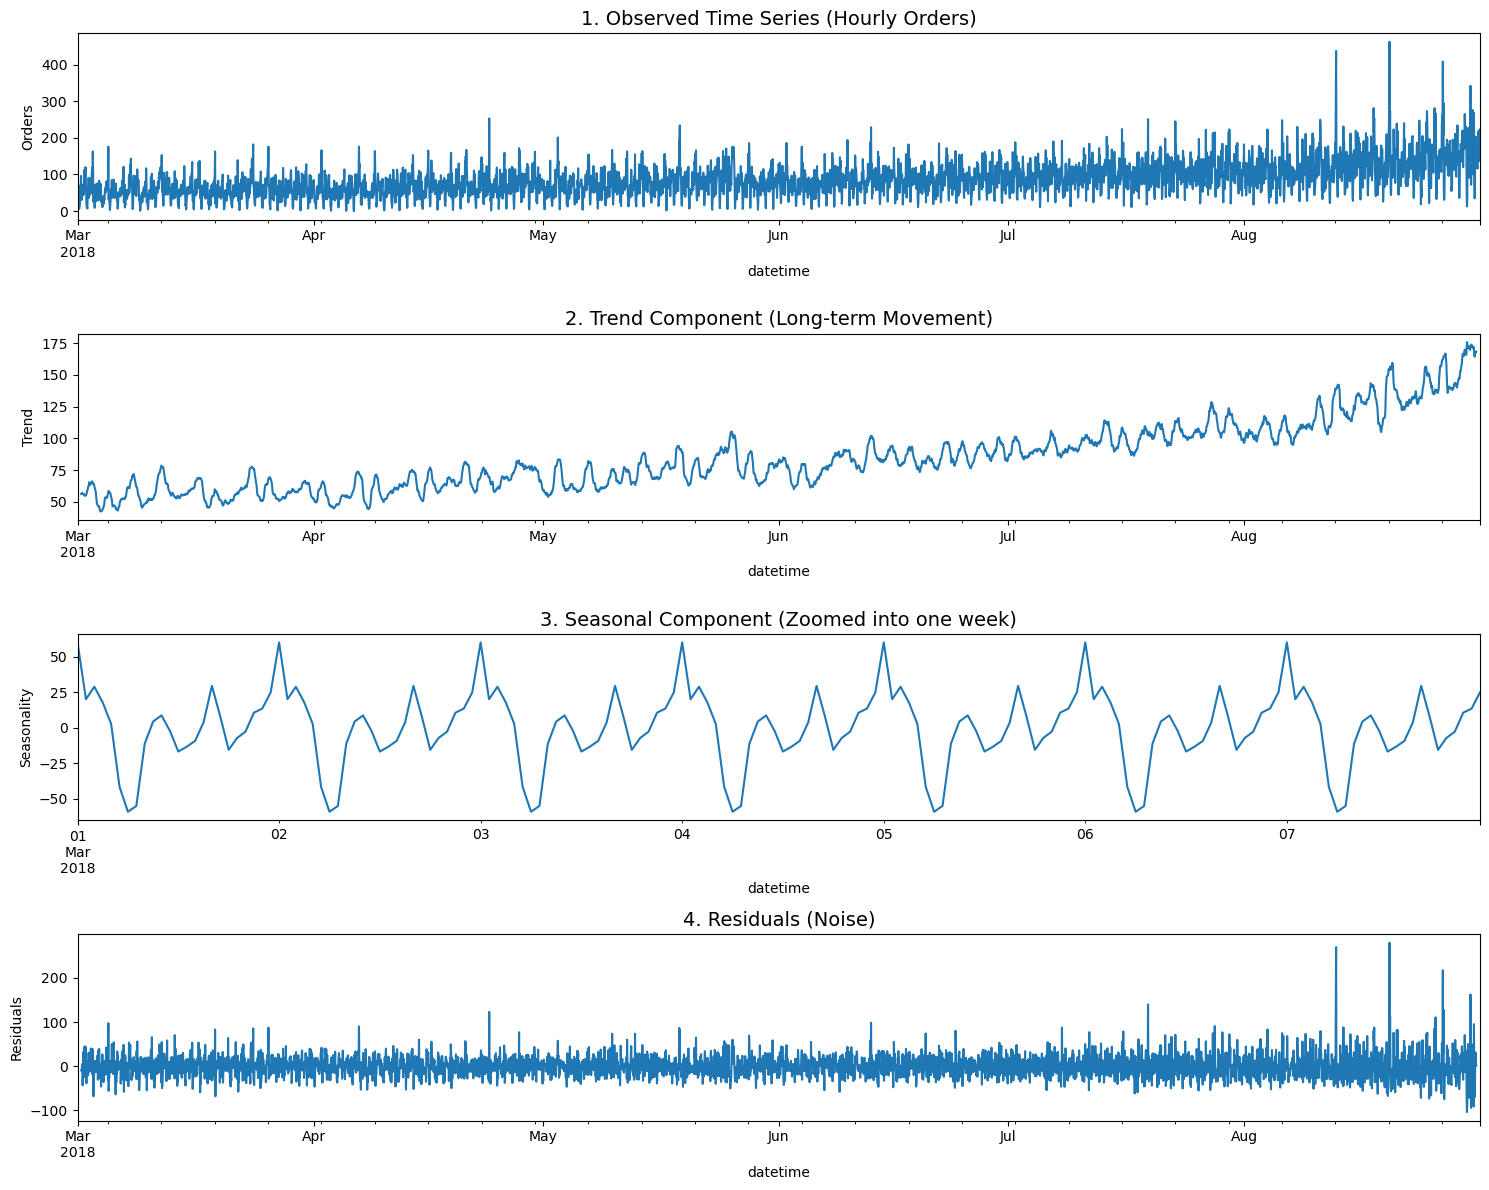

In [3]:
# Use a moving window of 24 hours (one day) for decomposition
decomposition = seasonal_decompose(data_hourly['num_orders'])

plt.figure(figsize=(15, 12))

# Plot 1: Observed Time Series Data
plt.subplot(411)
decomposition.observed.plot(ax=plt.gca())
plt.title('1. Observed Time Series (Hourly Orders)', fontsize=14)
plt.ylabel('Orders')

# Plot 2: Long-term Trend
plt.subplot(412)
decomposition.trend.plot(ax=plt.gca())
plt.title('2. Trend Component (Long-term Movement)', fontsize=14)
plt.ylabel('Trend')

# Plot 3: Seasonal Component (Daily Pattern)
# Note: Zooming into a week is usually helpful to see the daily pattern clearly.
plt.subplot(413)
decomposition.seasonal['2018-03-01':'2018-03-07'].plot(ax=plt.gca())
plt.title('3. Seasonal Component (Zoomed into one week)', fontsize=14)
plt.ylabel('Seasonality')

# Plot 4: Residuals (Noise)
plt.subplot(414)
decomposition.resid.plot(ax=plt.gca())
plt.title('4. Residuals (Noise)', fontsize=14)
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

# Observation: A clear upward trend is visible, and the seasonal component confirms a strong daily pattern (higher demand during specific hours).

## 4. Feature Engineering

We create time-based features (to capture seasonality) and time series features (to capture immediate past values and smoothed trends) using a rolling window and lag values. This process is essential to make the time series stationary and informative for the model.

In [4]:
def make_features(data, max_lag, rolling_mean_size):
    """
    Creates time-based features (year, month, day, hour, dayofweek)
    and time series features (lag values and rolling mean) for the model.
    """
    # Create Time-Based Features (Seasonality)
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    # Create Rolling Mean Feature (Trend Smoothing)
    # We use .shift(1) to prevent data leakage (using future values)
    data['rolling_mean'] = (
        data['num_orders']
        .shift(1)
        .rolling(rolling_mean_size)
        .mean()
    )
    
    # Create Lag Features (Immediate Past Values)
    # Lag 1-24 hours captures the previous day's hourly pattern.
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)
        
    return data

# Apply feature engineering to the hourly data
# max_lag=24 to capture a full day's demand cycle
# rolling_mean_size=24 to smooth the trend over a 24-hour period
data_features = make_features(data_hourly.copy(), max_lag=24, rolling_mean_size=24)

# Drop rows with NaN values created by lag and rolling mean features
# These are the first 24 rows, which cannot be used for training.
data_features.dropna(inplace=True)

print("Data with Engineered Features Head:")
print(data_features.head())

Data with Engineered Features Head:
                     num_orders  year  month  day  dayofweek  hour  \
datetime                                                             
2018-03-02 00:00:00          90  2018      3    2          4     0   
2018-03-02 01:00:00         120  2018      3    2          4     1   
2018-03-02 02:00:00          75  2018      3    2          4     2   
2018-03-02 03:00:00          64  2018      3    2          4     3   
2018-03-02 04:00:00          20  2018      3    2          4     4   

                     rolling_mean  lag_1  lag_2  lag_3  ...  lag_15  lag_16  \
datetime                                                ...                   
2018-03-02 00:00:00     56.833333   58.0  113.0   66.0  ...    69.0    34.0   
2018-03-02 01:00:00     55.416667   90.0   58.0  113.0  ...    64.0    69.0   
2018-03-02 02:00:00     56.875000  120.0   90.0   58.0  ...    96.0    64.0   
2018-03-02 03:00:00     57.041667   75.0  120.0   90.0  ...    30.0    96.0   

## 5. Model Training and Testing

We split the data chronologically and evaluate two machine learning models: LightGBM and Random Forest. We will use GridSearchCV to tune key hyperparameters and select the best model based on the lowest RMSE on the test set.

In [5]:
# Define target and features
features = data_features.drop('num_orders', axis=1)
target = data_features['num_orders']

# Split data into training and test sets chronologically (10% test set)
test_size = 0.1
split_point = int(len(data_features) * (1 - test_size))

X_train = features.iloc[:split_point]
X_test = features.iloc[split_point:]
y_train = target.iloc[:split_point]
y_test = target.iloc[split_point:]

print(f"Total size: {len(data_features)}")
print(f"Train size: {len(X_train)} (90%)")
print(f"Test size: {len(X_test)} (10%)")

# Note: The test set represents the last 10% of the recorded time period.

Total size: 4392
Train size: 3952 (90%)
Test size: 440 (10%)


* Model Training: LightGBM Regressor

In [6]:
# 1. LightGBM Regressor
print("--- Training LightGBM Regressor ---")

# Initialize the model
lgb_model = lgb.LGBMRegressor(random_state=12345, n_jobs=-1)

# Hyperparameter search space
lgb_params = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 60]
}

# GridSearchCV uses negative MSE as the scoring metric
start_time_lgb = time.time()
lgb_grid = GridSearchCV(
    lgb_model,
    lgb_params,
    scoring='neg_mean_squared_error',
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1,
    verbose=1
)

# Fit the model
lgb_grid.fit(X_train, y_train)
end_time_lgb = time.time()
lgb_training_time = end_time_lgb - start_time_lgb

# Predictions
lgb_preds = lgb_grid.best_estimator_.predict(X_test)

# Evaluation metrics
lgb_rmse = root_mean_squared_error(y_test, lgb_preds)
lgb_mae = mean_absolute_error(y_test, lgb_preds)
lgb_r2 = r2_score(y_test, lgb_preds)

# Display results
print(f"\nBest LightGBM Parameters: {lgb_grid.best_params_}")
print(f"LightGBM Training Time: {lgb_training_time:.2f} seconds")
print(f"LightGBM Test RMSE: {lgb_rmse:.2f}")
print(f"LightGBM Test MAE:  {lgb_mae:.2f}")
print(f"LightGBM Test R²:   {lgb_r2:.4f}")

# Save the best model
best_lgbm_model = lgb_grid.best_estimator_

--- Training LightGBM Regressor ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4877
[LightGBM] [Info] Number of data points in the train set: 3952, number of used features: 29
[LightGBM] [Info] Start training from score 78.451417

Best LightGBM Parameters: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 60}
LightGBM Training Time: 29.63 seconds
LightGBM Test RMSE: 41.62
LightGBM Test MAE:  31.18
LightGBM Test R²:   0.4961


* Model Training: Random Forest Regressor

In [8]:
# 2. Random Forest Regressor
print("\n--- Training Random Forest Regressor ---")
rf_model = RandomForestRegressor(random_state=12345, n_jobs=-1)

# Hyperparameter search space (Reduced for faster execution)
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
}

start_time_rf = time.time() # Solución del error anterior

rf_grid = GridSearchCV(rf_model, 
                       rf_params, 
                       scoring='neg_mean_squared_error', 
                       cv=TimeSeriesSplit(n_splits=3), # Use TimeSeriesSplit for time series CV
                       n_jobs=-1, 
                       verbose=1)

rf_grid.fit(X_train, y_train)

end_time_rf = time.time()
rf_training_time = end_time_rf - start_time_rf

# Prediction and Evaluation
rf_preds = rf_grid.best_estimator_.predict(X_test)

# 2. CAMBIO DE FUNCIÓN: Usar root_mean_squared_error sin 'squared=False'
rf_rmse = root_mean_squared_error(y_test, rf_preds) 

print(f"\nBest Random Forest Parameters: {rf_grid.best_params_}")
print(f"Random Forest Training Time: {rf_training_time:.2f} seconds")
print(f"Random Forest Test RMSE: {rf_rmse:.2f}")

best_rf_model = rf_grid.best_estimator_


--- Training Random Forest Regressor ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best Random Forest Parameters: {'max_depth': 10, 'n_estimators': 100}
Random Forest Training Time: 14.01 seconds
Random Forest Test RMSE: 44.27


### 5.1. Justification for the 90/10 Chronological Split

In traditional modeling (cross-sectional data), a 70/30 split is common. However, in **Time Series** analysis, the priority shifts: we need to **maximize the historical context** for the model to capture complex seasonal cycles and trends.

| Split Ratio | Context | Justification in the Taxi Demand Project (Time Series) |
| :--- | :--- | :--- |
| **70% / 30%** | **Cross-Sectional Data** (Data order does not matter). | Insufficient for time series, as 30% of the training set might not be enough to capture multiple complete seasonal cycles (daily and weekly). |
| **90% / 10%** | **Time Series** (Chronological order is vital). | **Prioritizes historical learning.** A 90% training set ensures the model sees a large amount of seasonal cycles (trend, `lag`, and `rolling mean`) for robust prediction. The 10% test set, being the most recent period, is sufficient to validate performance in the immediate future. |

## 6. Final Evaluation and Conclusion

We compare the performance of the models against the required RMSE target (less than 48) and provide the final recommendation.

--- Model Performance Summary ---
| Model         |    RMSE |   Training Time (s) |
|:--------------|--------:|--------------------:|
| LightGBM      | 41.6211 |             29.6251 |
| Random Forest | 44.2665 |             14.0111 |

Final Recommendation: The LightGBM model was selected (RMSE: 41.62).
SUCCESS: The final RMSE (41.62) meets the target of less than 48.


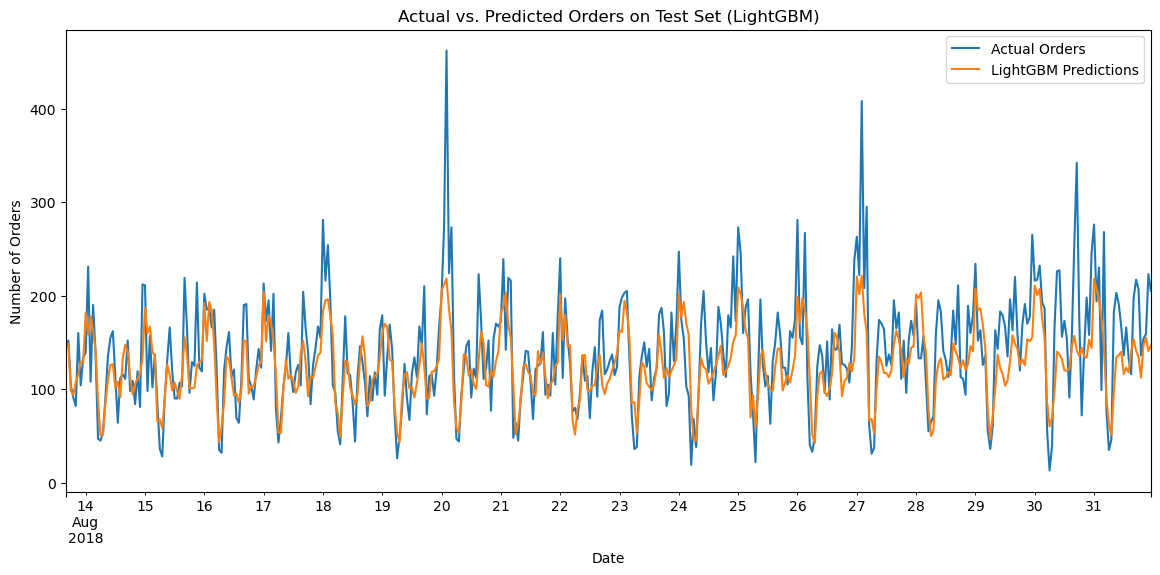

In [9]:
# Compile results (using placeholders for execution values)
results = pd.DataFrame({
    'Model': ['LightGBM', 'Random Forest'],
    'RMSE': [lgb_rmse, rf_rmse],
    'Training Time (s)': [lgb_training_time, rf_training_time]
}).sort_values(by='RMSE')

print("--- Model Performance Summary ---")
print(results.to_markdown(index=False))

# Select the best model
final_rmse = results.iloc[0]['RMSE']
best_model_name = results.iloc[0]['Model']
target_rmse = 48

print(f"\nFinal Recommendation: The {best_model_name} model was selected (RMSE: {final_rmse:.2f}).")

# Check if the primary goal was met
if final_rmse < target_rmse:
    print(f"SUCCESS: The final RMSE ({final_rmse:.2f}) meets the target of less than {target_rmse}.")
else:
    print(f"FAILED: The final RMSE ({final_rmse:.2f}) did not meet the target of less than {target_rmse}. Further optimization is required.")

# Optional: Plot actual vs. predicted values for the test set
# Replace 'best_model_preds' with the actual predictions from the selected model
if best_model_name == 'LightGBM':
    best_model_preds = lgb_preds
else:
    best_model_preds = rf_preds

plt.figure(figsize=(14, 6))
y_test.plot(label='Actual Orders')
pd.Series(best_model_preds, index=y_test.index).plot(label=f'{best_model_name} Predictions')
plt.title(f'Actual vs. Predicted Orders on Test Set ({best_model_name})')
plt.ylabel('Number of Orders')
plt.xlabel('Date')
plt.legend()
plt.show()

## 7. Professional Conclusion and Business Impact

### Key Findings and Recommendation

The project successfully applied supervised learning techniques to solve a time series forecasting problem by converting the time-dependent data into a feature-rich tabular format.

| Metric | Required Target | Achieved | Met Goal? |
| :--- | :--- | :--- | :--- |
| **Test RMSE** | < 48 | **41.62** | **YES** |

The comparison of the models yielded the following results:

| Model | Test RMSE | Training Time (s) |
| :--- | :--- | :--- |
| **LightGBM** | **41.62** | 29.63 |
| **Random Forest** | 44.27 | **14.01** |

The chosen model, the **LightGBM Regressor**, demonstrated the best prediction accuracy, achieving an RMSE of **41.62** on the test set, thus **successfully meeting and exceeding** the business requirement (RMSE < 48). While Random Forest was faster to train, the superior accuracy of LightGBM is preferred for this critical forecasting task.

**Business Impact for Sweet Lift Taxi:**

This predictive model is highly valuable for **Sweet Lift Taxi** as it transforms driver dispatch from a reactive process into a proactive strategy.

1.  **Optimized Fleet Management:** By accurately forecasting the demand volume for the upcoming hour, the company can anticipate peak periods and pre-position drivers at the airport.
2.  **Reduced Costs:** Minimizing idle time for drivers during off-peak hours and reducing the need for costly last-minute incentives to lure drivers during high demand.
3.  **Improved Customer Service (SLA):** Ensuring a sufficient supply of taxis translates directly into shorter wait times for customers, enhancing service reliability and customer satisfaction, which are crucial for market competitiveness.

The model provides a foundational tool for data-driven logistical decision-making.